# Frequency Decoding on Neurosoft Minipigs 2026

Minimal example: load a single session, extract fixed-length windows using
torch_brain's `SequentialFixedWindowSampler`, and train a logistic regression
on the **acoustic_stim** multiclass classification task (7 stimulation
frequencies, intrasession causal split).

In [27]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import os
import h5py
from temporaldata import Data

from auditorydecoding.windowing import extract_windows
from auditorydecoding.plotting import plot_signal, plot_pca_variance, plot_covariance, plot_spectrum
from scipy.signal import butter, sosfilt

In [29]:
WINDOW_LENGTH = 0.5  # seconds
FOLD_NUM = 0
SPLIT_TYPE = "intrasession-causal"
TASK_TYPE = "acoustic_stim"

DATA_ROOT = "../data/processed/neurosoft_minipigs_2026"
RECORDING_ID = "sub-06_ses-02_task-AcousStim_acq-LH_desc-raw"

## Load the data and preprocessing

In [30]:
path = os.path.join(DATA_ROOT, RECORDING_ID + ".h5")

with h5py.File(path) as f:
    data = Data.from_hdf5(f, lazy=False)

CHANNEL_NAMES = data.channels.id

Here, we load all the splits and coalesce them to make them contiguous. We can do this because we are getting the causal splits.

We also filter the channels to only keep the ECoG channels.

In [31]:
keep_channels = data.channels.type == "ecog"

channel_names = data.channels.id[keep_channels]
train_intervals = data.splits.acoustic_stim_causal_train.coalesce()
data_train = [data.slice(interval[0], interval[1]).ecog.signal[:, keep_channels] for interval in train_intervals]
data_train = np.concatenate(data_train, axis=0)

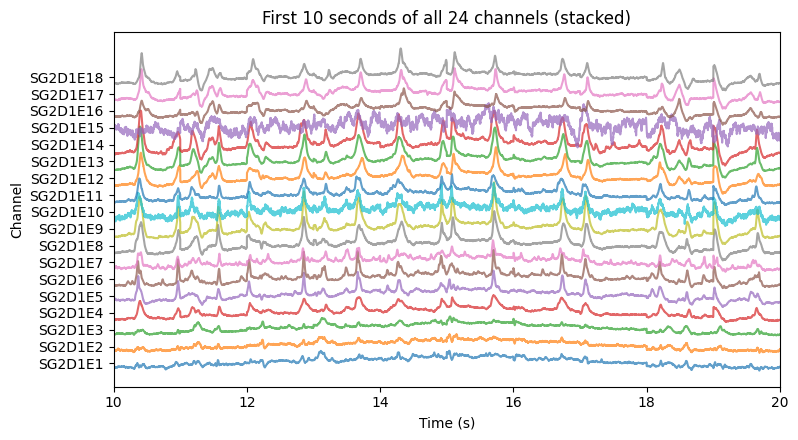

In [32]:
plot_signal(data_train, start=10, end=20, chann_names=channel_names)

## Preprocessing

In [33]:
signal = data.ecog.signal[:, keep_channels]
timestamps = data.ecog.timestamps

#### Bandpass Filtering

In [34]:
from scipy.signal import welch
def plot_spectrum2(signal, fs, lowcut=29, highcut=70):
    f, psd = welch(signal.flatten(), fs, nperseg=1023)

    plt.figure(figsize=(4, 3))
    plt.semilogy(f, psd, label="Original Signal", alpha=.7)
    plt.axvline(lowcut, color="k", linestyle="--", alpha=.7, label="Cutoffs")
    plt.axvline(highcut, color="k", linestyle="--", alpha=.7)
    plt.title("Power Spectral Density (PSD)")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD [V**1/Hz]")
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=.7)
    plt.show()

In [35]:
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    if data.ndim > 1:
        return np.array([bandpass_filter(data[:, i], lowcut, highcut, fs, order) for i in range(data.shape[1])]).T
    # Nyquist frequency is half the sampling rate
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    # Generate the filter coefficients in Second-Order Sections format
    sos = butter(order, [low, high], analog=False, btype='band', output='sos')
    y = sosfilt(sos, data)
    return y

FILTER_SIGNAL = True
if FILTER_SIGNAL:
    fs = 2000
    lowcut, highcut = 30, 300
    filtered_signal = bandpass_filter(signal, lowcut, highcut, fs, order=6)
    data_train = bandpass_filter(data_train, lowcut, highcut, fs, order=6)

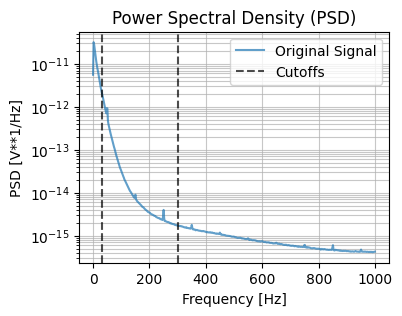

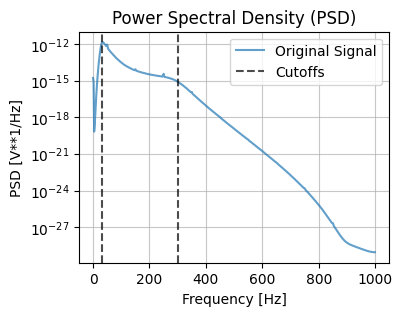

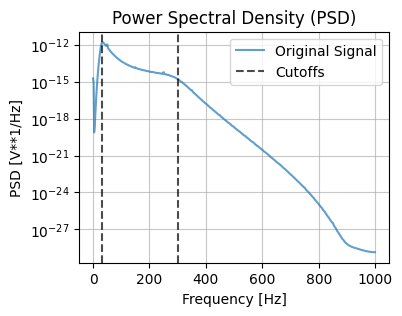

In [36]:
plot_spectrum2(signal[:, 0], fs, lowcut, highcut)
plot_spectrum2(filtered_signal[:, 0], fs, lowcut, highcut)
plot_spectrum2(data_train[:, 0], fs, lowcut, highcut)

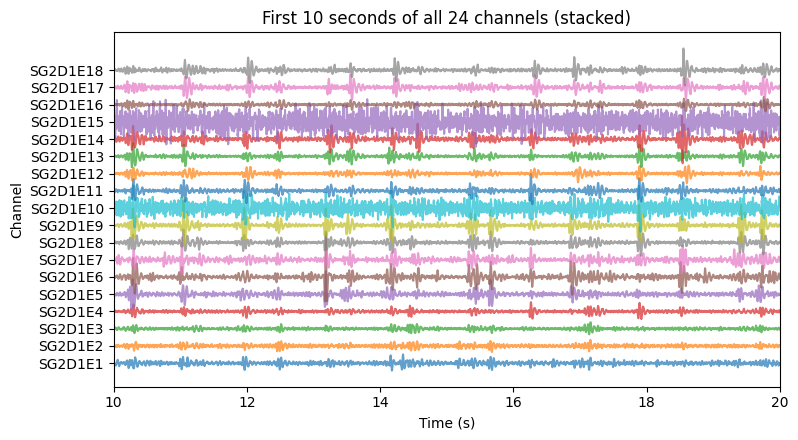

In [37]:
plot_signal(filtered_signal, start=10, end=20, chann_names=channel_names)

#### Whitening the data

We get the training split and then use this to fit the whitening model.

In [38]:
ZSCORE = False
if ZSCORE:
    data_train = (data_train - data_train.mean(axis=0)) / data_train.std(axis=0)

WHITENING = True
N_COMPONENTS = None
pca = PCA(whiten=WHITENING, n_components=N_COMPONENTS).fit(data_train)

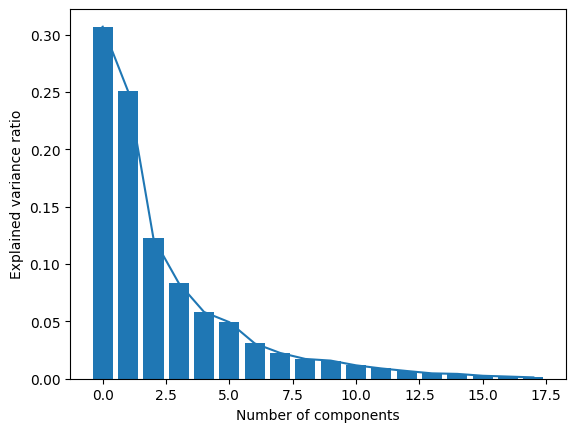

In [39]:
plot_pca_variance(pca)

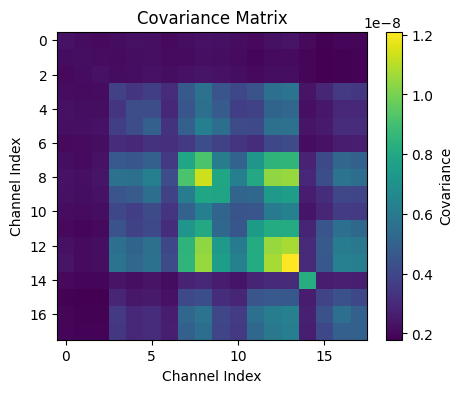

In [40]:
plot_covariance(np.cov(signal, rowvar=False))

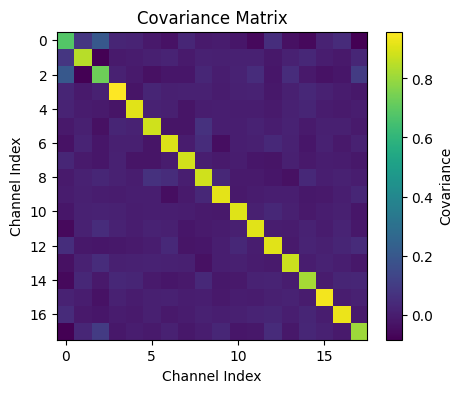

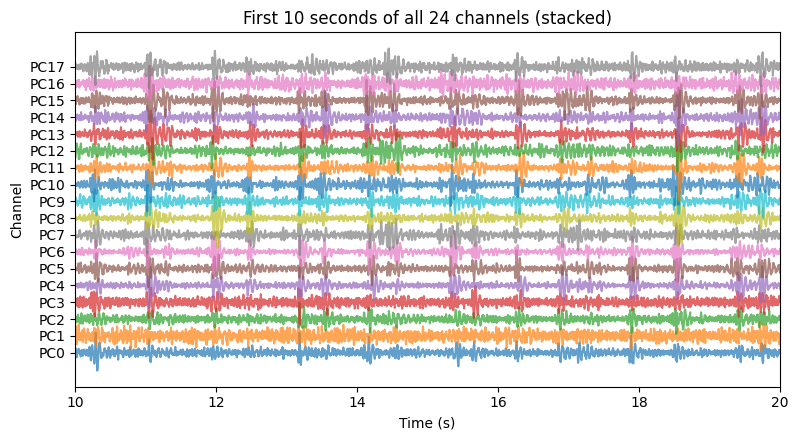

In [41]:
APPLY_WHITENING = True
if APPLY_WHITENING:
    signal_whitened = pca.transform(filtered_signal)
    plot_covariance(np.cov(signal_whitened, rowvar=False))
    plot_signal(signal_whitened, start=10, end=20, chann_names=[f"PC{i}" for i in range(signal_whitened.shape[1])])
else:
    signal_whitened = filtered_signal

NORM_BY_CHANNEL = False
if NORM_BY_CHANNEL:
    train_transformed = pca.transform(data_train)
    signal_whitened = (signal_whitened - train_transformed.mean(axis=0)) / train_transformed.std(axis=0)

    plot_covariance(np.cov(signal_whitened, rowvar=False))

## Get windows and feature matrix

In [42]:
X_windows_train, y_windows_train = extract_windows(signal_whitened, timestamps, data.splits.acoustic_stim_causal_train, WINDOW_LENGTH)
X_windows_valid, y_windows_valid = extract_windows(signal_whitened, timestamps, data.splits.acoustic_stim_causal_valid, WINDOW_LENGTH)

le = LabelEncoder().fit(y_windows_train)
y_train_enc = le.transform(y_windows_train)
y_valid_enc = le.transform(y_windows_valid)

for name, X, y in [
    ("train", X_windows_train, y_windows_train),
    ("valid", X_windows_valid, y_windows_valid),
]:
    unique, counts = np.unique(y, return_counts=True)
    dist = ", ".join(f"{u}: {c}" for u, c in zip(unique, counts))
    print(f"{name:>5s}  X={X.shape}  y={y.shape}  classes={{ {dist} }}")

Extracting windows:   0%|          | 0/1348 [00:00<?, ?it/s]

Extracting windows: 100%|██████████| 217/217 [00:02<00:00, 100.11it/s]

train  X=(1348, 1000, 18)  y=(1348,)  classes={ stim_10000Hz: 146, stim_1000Hz: 72, stim_15000Hz: 71, stim_16000Hz: 72, stim_20000Hz: 144, stim_2000Hz: 144, stim_300Hz: 70, stim_5000Hz: 73, stim_500Hz: 73, stim_8000Hz: 71, stim_800Hz: 146, stim_wn: 266 }
valid  X=(217, 1000, 18)  y=(217,)  classes={ stim_10000Hz: 24, stim_1000Hz: 12, stim_15000Hz: 11, stim_16000Hz: 12, stim_20000Hz: 24, stim_2000Hz: 23, stim_300Hz: 11, stim_5000Hz: 12, stim_500Hz: 12, stim_8000Hz: 11, stim_800Hz: 23, stim_wn: 42 }


### Do the feature extraction here

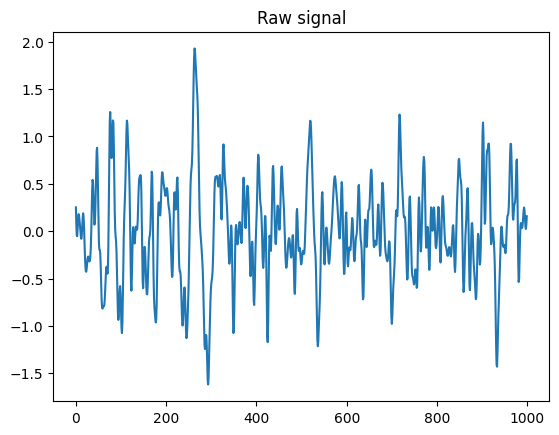

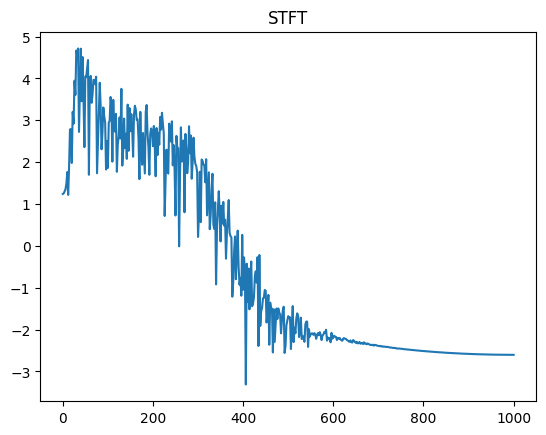

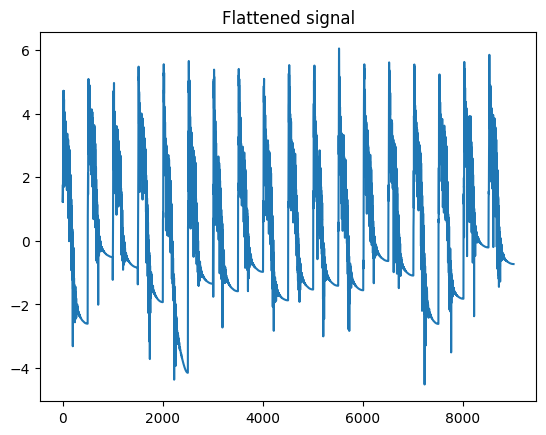

In [43]:
from einops import rearrange

X_train = X_windows_train
X_valid = X_windows_valid
y_train = y_windows_train
y_valid = y_windows_valid

plt.plot(X_train[0, :, 0])
plt.title("Raw signal")
plt.show()

STFT = True
CROP_FREQS = False
if STFT:
    X_train = np.log(np.abs(np.fft.rfft(X_train, axis=1)))
    X_valid = np.log(np.abs(np.fft.rfft(X_valid, axis=1)))
    freqs = np.fft.rfftfreq(int(0.5 * fs), d=1/fs)

    plt.plot(freqs, X_train[0, :, 0])
    plt.title("STFT")
    plt.show()

    if CROP_FREQS:
        valid_indices = (freqs >= lowcut) & (freqs <= highcut)
        
        X_train = X_train[:, valid_indices, :]
        X_valid = X_valid[:, valid_indices, :]
        plt.plot(freqs[valid_indices], X_train[0, :, 0])
        plt.title("Cropped STFT")
        plt.show()

ZSCORE = False
if ZSCORE:
    X_train_mean = X_train.mean(axis=0)
    X_train_std = X_train.std(axis=0)
    X_train = (X_train - X_train_mean) / (X_train_std + 1e-8)
    X_valid = (X_valid - X_train_mean) / (X_train_std + 1e-8)

    plt.plot(X_train[0, :, 0])
    plt.title("Z-scored signal (axis 0)")
    plt.show()

STD = False
if STD:
    X_train = (X_train - X_train.mean(axis=1, keepdims=True)) / (X_train.std(axis=1, keepdims=True) + 1e-8)
    X_valid = (X_valid - X_valid.mean(axis=1, keepdims=True)) / (X_valid.std(axis=1, keepdims=True) + 1e-8)

    plt.plot(X_train[0, :, 0])
    plt.title("Z-scored signal (axis 1)")
    plt.show()

FLATTEN = True
if FLATTEN:
    X_train = rearrange(X_train, "s t c -> s (c t)")
    X_valid = rearrange(X_valid, "s t c -> s (c t)")

    plt.plot(X_train[0, :])
    plt.title("Flattened signal")
    plt.show()

Feature matrix shapes:  train (1348, 9018)  valid (217, 9018)


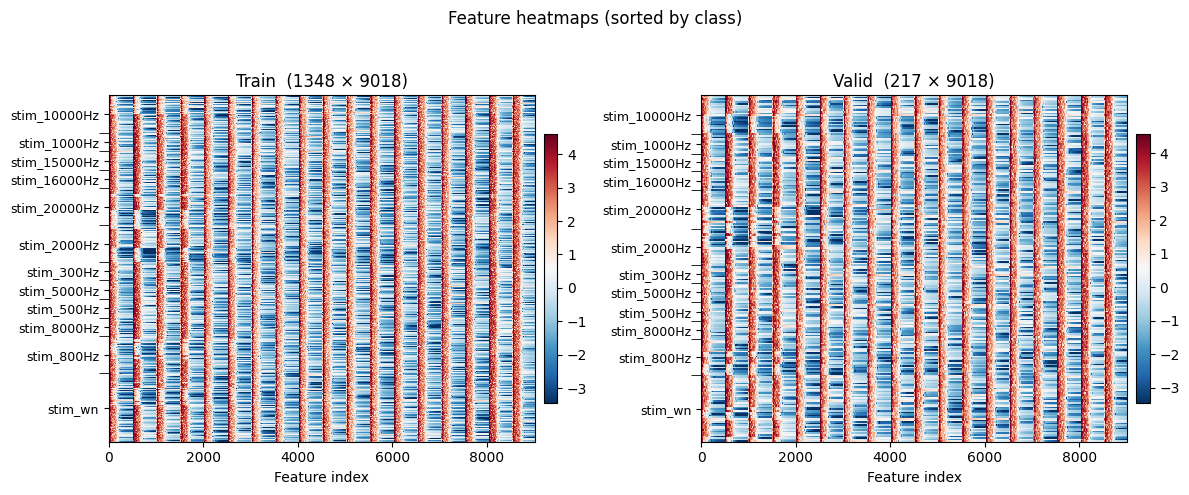

In [44]:
print(f"Feature matrix shapes:  train {X_train.shape}  valid {X_valid.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, X, y_enc, title in [
    (axes[0], X_train, y_train_enc, "Train"),
    (axes[1], X_valid, y_valid_enc, "Valid"),
]:
    order = np.argsort(y_enc)
    im = ax.imshow(
        X[order],
        aspect="auto",
        interpolation="none",
        cmap="RdBu_r",
        vmin=np.percentile(X, 2),
        vmax=np.percentile(X, 98),
    )

    boundaries = np.searchsorted(y_enc[order], np.arange(len(le.classes_)))

    # Instead of drawing black lines, put ticks between the classes (not on labels):
    between_ticks = boundaries[1:]
    ax.set_yticks(between_ticks, minor=True)
    ax.tick_params(axis='y', which='minor', length=7, color='k')

    label_positions = [
        (boundaries[i] + (boundaries[i + 1] if i + 1 < len(boundaries) else len(y_enc))) / 2
        for i in range(len(boundaries))
    ]
    ax.set_yticks(label_positions)
    ax.set_yticklabels(le.classes_, fontsize=9)

    ax.set_xlabel("Feature index")
    ax.set_title(f"{title}  ({X.shape[0]} \u00d7 {X.shape[1]})")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

fig.suptitle("Feature heatmaps (sorted by class)")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Train the model

In [45]:
clf = LogisticRegression(max_iter=10_000)
clf.fit(X_train, y_train_enc)

val_acc = accuracy_score(y_valid_enc, clf.predict(X_valid))

print(f"Validation accuracy: {val_acc:.3f}")
print()
print(
    classification_report(
        y_valid_enc,
        clf.predict(X_valid),
        target_names=le.classes_,
    )
)

Validation accuracy: 0.198

              precision    recall  f1-score   support

stim_10000Hz       0.22      0.21      0.21        24
 stim_1000Hz       0.40      0.33      0.36        12
stim_15000Hz       0.00      0.00      0.00        11
stim_16000Hz       0.18      0.25      0.21        12
stim_20000Hz       0.14      0.12      0.13        24
 stim_2000Hz       0.13      0.09      0.11        23
  stim_300Hz       0.14      0.09      0.11        11
 stim_5000Hz       0.29      0.17      0.21        12
  stim_500Hz       0.00      0.00      0.00        12
 stim_8000Hz       0.00      0.00      0.00        11
  stim_800Hz       0.19      0.26      0.22        23
     stim_wn       0.25      0.40      0.31        42

    accuracy                           0.20       217
   macro avg       0.16      0.16      0.16       217
weighted avg       0.18      0.20      0.18       217



In [46]:
clf.coef_
print(clf.coef_.shape)
print(clf.coef_[0, :])
print(clf.coef_[0, :].shape)
print(clf.coef_[0, :].argmax())

per_channel_weights = clf.coef_.reshape(7 * 24, -1)
plt.plot(per_channel_weights.mean(axis=0))
plt.title("Per-channel weights")
plt.show()

(12, 9018)
[ 0.04538009  0.03914396  0.02276979 ... -0.00535406 -0.00706793
 -0.00852215]
(9018,)
4692


ValueError: cannot reshape array of size 108216 into shape (168,newaxis)

## Statistical Test: Is Performance Above Chance?

The test set is unbalanced, so raw accuracy alone is misleading. Two complementary tests are used:

- **Binomial test** (exact): tests whether raw accuracy exceeds the majority-class baseline (the accuracy a trivial \"always predict majority\" classifier would achieve).
- **Permutation test**: shuffles the test labels 10 000 times and recomputes **balanced accuracy** against the fixed model predictions each time. Balanced accuracy averages per-class recall, so its chance level is always `1 / n_classes` regardless of class proportions. The p-value is the fraction of permutations that matched or exceeded the observed balanced accuracy.

Validation set class counts  : stim_10000Hz=24, stim_1000Hz=12, stim_15000Hz=11, stim_16000Hz=12, stim_20000Hz=24, stim_2000Hz=23, stim_300Hz=11, stim_5000Hz=12, stim_500Hz=12, stim_8000Hz=11, stim_800Hz=23, stim_wn=42
Majority-class chance        : 0.194
Uniform chance (1/12)         : 0.083

Observed accuracy            : 0.198
Observed balanced acc        : 0.161

Binomial test  p-value : 0.4588  (H0: acc ≤ 0.194)
Permutation    p-value : 0  (n=10,000 permutations, balanced acc)


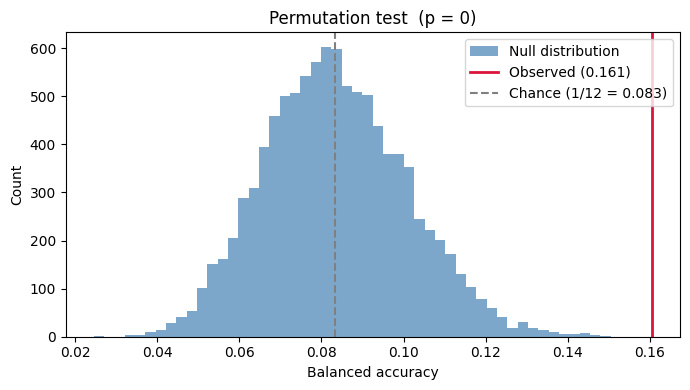

In [47]:
from scipy.stats import binomtest
from sklearn.metrics import balanced_accuracy_score

N_PERMUTATIONS = 10_000
n_classes = len(le.classes_)

y_pred_valid = clf.predict(X_valid)

_, counts = np.unique(y_valid_enc, return_counts=True)
majority_chance = counts.max() / counts.sum()

n_correct = (y_pred_valid == y_valid_enc).sum()
n_total = len(y_valid_enc)
observed_acc = n_correct / n_total
observed_bal_acc = balanced_accuracy_score(y_valid_enc, y_pred_valid)

# --- Binomial test (raw accuracy vs. majority-class baseline) ---
binom_result = binomtest(n_correct, n_total, p=majority_chance, alternative="greater")

# --- Permutation test (balanced accuracy; chance = 1/n_classes by construction) ---
rng = np.random.default_rng(0)
null_bal_accs = np.array([
    balanced_accuracy_score(rng.permutation(y_valid_enc), y_pred_valid)
    for _ in range(N_PERMUTATIONS)
])
permutation_pvalue = (null_bal_accs >= observed_bal_acc).mean()

class_counts_str = ", ".join(
    f"{le.classes_[c]}={counts[c]}" for c in range(n_classes)
)
uniform_chance = 1.0 / n_classes
print(f"Validation set class counts  : {class_counts_str}")
print(f"Majority-class chance        : {majority_chance:.3f}")
print(f"Uniform chance (1/{n_classes})         : {uniform_chance:.3f}")
print()
print(f"Observed accuracy            : {observed_acc:.3f}")
print(f"Observed balanced acc        : {observed_bal_acc:.3f}")
print()
print(f"Binomial test  p-value : {binom_result.pvalue:.4g}  (H0: acc \u2264 {majority_chance:.3f})")
print(f"Permutation    p-value : {permutation_pvalue:.4g}  (n={N_PERMUTATIONS:,} permutations, balanced acc)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(null_bal_accs, bins=50, color="steelblue", alpha=0.7, label="Null distribution")
ax.axvline(observed_bal_acc, color="crimson", linewidth=2, label=f"Observed ({observed_bal_acc:.3f})")
ax.axvline(uniform_chance, color="gray", linewidth=1.5, linestyle="--", label=f"Chance (1/{n_classes} = {uniform_chance:.3f})")
ax.set_xlabel("Balanced accuracy")
ax.set_ylabel("Count")
ax.set_title(f"Permutation test  (p = {permutation_pvalue:.4g})")
ax.legend()
plt.tight_layout()
plt.show()

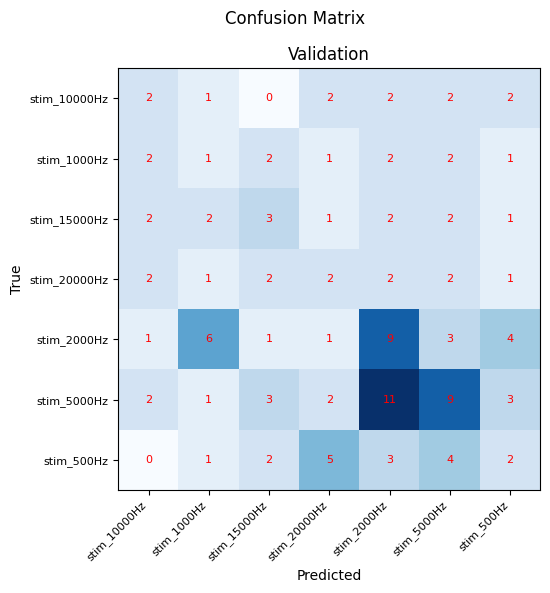

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

y_true = y_valid_enc
y_pred = clf.predict(X_valid)
cm = confusion_matrix(y_true, y_pred)
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(le.classes_, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(le.classes_, fontsize=8)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Validation")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "red"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=8)

fig.suptitle("Confusion Matrix")
fig.tight_layout()
plt.show()